<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture05/slide-001.png" class="img-responsive"/>
</div>



In [ ]:
from collections import Counter

def count_chars(input_str):
    return Counter(input_str)

print(count_chars('hello there'))

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture05/slide-002.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture05/slide-003.png" class="img-responsive"/>
</div>


In [ ]:
def replace_pairs(lst, target_pair, combined_id):
    new_lst = []

    i = 0
    while i < len(lst):
        if (lst[i], lst[i+1]) == target_pair:
            new_lst.append(combined_id)
            i += 2
        else:
            new_lst.append(lst[i])
            i += 1

    return new_lst


print(replace_pairs([1, 2, 3, 1, 2], (1, 2), 4))
#[4, 3, 4]

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture05/slide-004.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture05/slide-005.png" class="img-responsive"/>
</div>



In [ ]:
import os

try:
    import google.colab
    REPO_URL = "https://github.com/wtheisen/nd-cse-10124-lectures.git"

    REPO_NAME = "/content/nd-cse-10124-lectures"
    L_PATH = "nd-cse-10124-lectures/Datasets"

    %cd /content/
    !rm -r {REPO_NAME}

    # Clone repo
    if not os.path.exists(REPO_NAME):
        !git clone {REPO_URL}

        # cd into the data folder
        %cd {L_PATH}
        !pwd

except ImportError:
    print("Unable to download repo, either:")
    print("\tA.) You're not on colab")
    print("\tB.) It has already been cloned")


import utilities as uts

# Install once (Colab-friendly)
!pip install -q gensim

import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt

# ----------------
# Load GloVe
# ----------------
print("Loading GloVe vectors (300d)...")
model = api.load("glove-wiki-gigaword-300")
print("Done.")


Projection onto gender axis (negative = masculine, positive = feminine):

boss            -1.049
manager         -0.947
leader          -0.774
gun             -0.604
engineer        -0.560
money           -0.551
authority       -0.366
programmer      -0.218
success         -0.192
soldier         -0.085
janitor         -0.043
scientist        0.070
cat              0.138
lawyer           0.285
pink             0.691
doctor           0.807
recipe           0.842
therapy          0.880
teacher          1.197
receptionist     1.454
homemaker        1.709
nurse            1.863


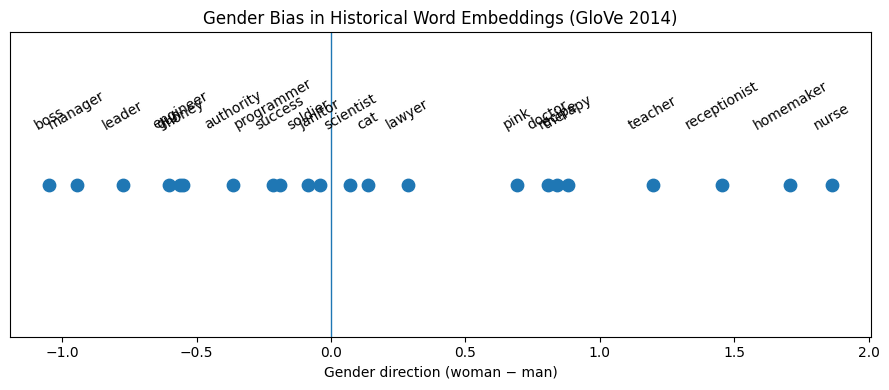

In [70]:
# ================================
# Historical NLP Bias Demonstration
# Using GloVe (2014)
# ================================

# ----------------
# Cosine similarity
# ----------------
def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# ----------------
# Build gender axis
# ----------------
gender_axis = model["woman"] - model["man"]
gender_axis = gender_axis / np.linalg.norm(gender_axis)

# ----------------
# Project words
# ----------------
def project(word):
    v = model[word]
    return np.dot(v, gender_axis)

# ----------------
# Test words
# ----------------
occupations = [
    "doctor",
    "nurse",
    "engineer",
    "scientist",
    "programmer",
    "teacher",
    "receptionist",
    "homemaker",
    "lawyer",
    "manager",
    "janitor",
    "soldier",
    "cat",
    "pink",
    "leader",
    "boss",
    "authority",
    "recipe",
    "therapy",
    "success",
    "gun",
    "money",
]

values = [(w, project(w)) for w in occupations]
values.sort(key=lambda x: x[1])

# ----------------
# Print results
# ----------------
print("\nProjection onto gender axis (negative = masculine, positive = feminine):\n")
for w, v in values:
    print(f"{w:15s} {v: .3f}")

# ----------------
# Visualization
# ----------------
words = [w for w, _ in values]
vals = np.array([v for _, v in values])

plt.figure(figsize=(9, 4))
plt.axvline(0.0, linewidth=1)
plt.scatter(vals, np.zeros_like(vals), s=80)

for w, v in zip(words, vals):
    plt.text(v, 0.02, w, ha="center", rotation=30)

plt.yticks([])
plt.xlabel("Gender direction (woman − man)")
plt.title("Gender Bias in Historical Word Embeddings (GloVe 2014)")
plt.tight_layout()
plt.show()

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture04/slide-019.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture04/slide-020.png" class="img-responsive"/>
</div>

In [53]:
import torch
from transformers import AutoTokenizer, AutoModel

def cos_sim(a, b):
    return torch.nn.functional.cosine_similarity(a, b, dim=0).item()

def token_embedding(word):
    # If the word splits into multiple wordpieces, you'll get multiple vectors.
    ids = tokenizer(word, add_special_tokens=False)["input_ids"]
    toks = tokenizer.convert_ids_to_tokens(ids)
    vecs = E[ids]  # (num_pieces, hidden_dim)
    return toks, ids, vecs

def project(word):
    _, _, v = token_embedding(word)
    return torch.dot(v[0], gender_axis).item()

model_name = "roberta-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

# embedding matrix: (vocab_size, hidden_dim)
E = model.get_input_embeddings().weight.detach().cpu()

t_dirty, ids_dirty, v_dirty = token_embedding("dirty")
t_clean, ids_clean, v_clean = token_embedding("clean")
t_apple, ids_apple, v_apple = token_embedding("apple")

# single-token words in roberta-large => one vector each
print(t_dirty, t_clean, t_apple)
print("dirty vs clean:", cos_sim(v_dirty[0], v_clean[0]))
print("dirty vs apple:", cos_sim(v_dirty[0], v_apple[0]))

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


['dirty'] ['clean'] ['apple']
dirty vs clean: 0.6328537464141846
dirty vs apple: 0.40697360038757324


king -1.2441926002502441
queen 1.410764217376709
man -0.6769390106201172
woman 0.9946282505989075
actor -0.8528489470481873
actress 1.228593349456787
boy -0.9709426760673523
girl 0.8710052371025085
apple 0.107982337474823
doctor -0.09884148836135864
tank -0.12432736903429031


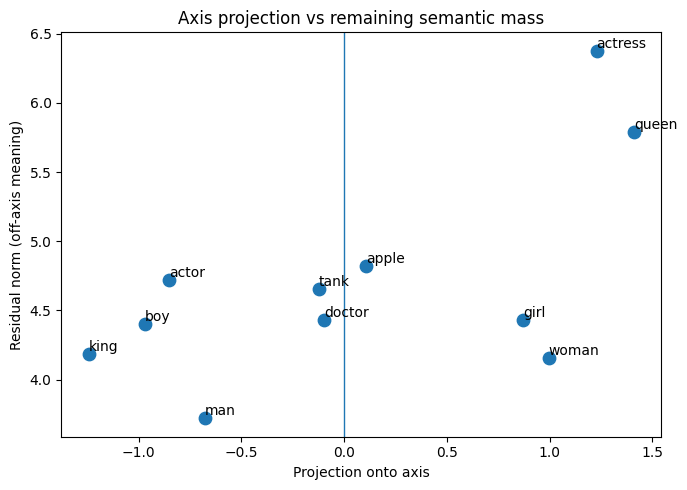

In [62]:
import matplotlib.pyplot as plt

def visualize_axis_with_residual(words, token_vec_fn, axis_unit):
    xs = []
    ys = []
    for w in words:
        _, _, v = token_vec_fn(w)           # (D,)
        x = torch.dot(v[0], axis_unit)         # scalar projection
        v_perp = v - x * axis_unit          # residual component
        y = torch.norm(v_perp)              # magnitude off-axis
        xs.append(x)
        ys.append(y)

    xs = torch.stack(xs)
    ys = torch.stack(ys)

    plt.figure(figsize=(7, 5))
    plt.scatter(xs.tolist(), ys.tolist(), s=80)

    for w, x, y in zip(words, xs, ys):
        plt.text(x.item(), y.item(), w, ha="left", va="bottom")

    plt.axvline(0.0, linewidth=1)
    plt.xlabel("Projection onto axis")
    plt.ylabel("Residual norm (off-axis meaning)")
    plt.title("Axis projection vs remaining semantic mass")
    plt.tight_layout()
    plt.show()

pairs = [
    ("king", "queen"),
    ("man", "woman"),
    ("actor", "actress"),
    ("prince", "princess"),
    ("boy", "girl"),
]

diffs = []

for a, b in pairs:
    _, _, va = token_embedding(a)
    _, _, vb = token_embedding(b)
    diffs.append(vb[0] - va[0])

gender_axis = torch.stack(diffs).mean(dim=0)
gender_axis = gender_axis / torch.norm(gender_axis)

proj = {}
for w in ["king", "queen", "man", "woman", "actor", "actress", "boy", "girl", "apple", "doctor", "tank"]:
    proj[w] = project(w)
    print(w, proj[w])

visualize_axis_with_residual(list(proj.keys()), token_embedding, gender_axis)

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture04/slide-021.png" class="img-responsive"/>
</div>

<div class="thumbnail">
    <img src="https://williamtheisen.com/nd-cse-10124-lectures/Lecture_Images/Lecture04/slide-022.png" class="img-responsive"/>
</div>

## Export to HTML

Uncomment the final line of the cell below and run it to export this notebook to HTML

In [ ]:
import os, json

def export_notebook():
  L_PATH = "nd-cse-10124-lectures/Notebooks"
  L = "Lecture_06_Embeddings_01"

  try:
      from google.colab import _message, files

      # where you WANT it to live (repo folder)
      repo_ipynb_path = f"/content/{L_PATH}/{L}.ipynb"

      # grab current notebook contents from the UI
      nb = _message.blocking_request("get_ipynb", timeout_sec=1)["ipynb"]

      # write it into the repo folder as a real file
      os.makedirs(os.path.dirname(repo_ipynb_path), exist_ok=True)
      with open(repo_ipynb_path, "w", encoding="utf-8") as f:
          json.dump(nb, f)

      # convert + download pdf
      !jupyter nbconvert --to html "{repo_ipynb_path}"
      files.download(repo_ipynb_path.replace(".ipynb", ".html"))
  except:
      import subprocess

      nb_fp = os.getcwd() + f'{L}.ipynb'
      print(os.getcwd())

      subprocess.run(["jupyter", "nbconvert", "--to", "html", nb_fp], check=True)

#export_notebook()